# RFSV Forecasting Model

This notebook implements the Rough Fractional Stochastic Volatility (RFSV) forecasting model used in the thesis.

The model uses the Hurst exponent estimated via Randomized Kolmogorov–Smirnov and constructs a fractional power-law memory feature to forecast one-day-ahead log-realized volatility.

The RFSV model is evaluated using MSE and QLIKE, and its predictions are saved for later comparison against the HAR-RV benchmark.

In [2]:
# ============================================================
# RFSV FORECASTING MODEL
# Master's Thesis: From Fractional to Rough Volatility
# Author: Elisa Battista
# ============================================================

import os
import glob
import math
import numpy as np
import pandas as pd

from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
from sklearn.linear_model import Ridge
from google.colab import drive

# ------------------------------------------------------------
# Google Drive Setup
# ------------------------------------------------------------

MOUNTPOINT = "/content/drive"

if not os.path.isdir(f"{MOUNTPOINT}/MyDrive"):
    drive.mount(MOUNTPOINT)

BASE = f"{MOUNTPOINT}/MyDrive/thesis"

CLEAN_DIR = f"{BASE}/data/clean"
SPLIT_DIR = f"{BASE}/data/splits"
RESULTS_DIR = f"{BASE}/results/metrics"
PRED_DIR = f"{BASE}/results/preds"
FIG_DIR = f"{BASE}/results/figures"

for folder in [RESULTS_DIR, PRED_DIR, FIG_DIR]:
    os.makedirs(folder, exist_ok=True)

RKS_CSV = f"{RESULTS_DIR}/hurst_randomizedKS_summary.csv"

OUT_CSV = f"{RESULTS_DIR}/rfsv_summary.csv"
OUT_LATEX = f"{RESULTS_DIR}/rfsv_table.tex"

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

ALPHA_GRID = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
K_GRID = [60, 90, 120, 180, 210, 252, 300, 330, 360]

MIN_OBS_SAFE = max(K_GRID) + 30

# ------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------

def log(message):
    print(f"[RFSV] {message}")


def discover_clean_files(clean_dir):
    paths = sorted(glob.glob(os.path.join(clean_dir, "*.csv")))
    files = {}

    for path in paths:
        try:
            head = pd.read_csv(path, nrows=10)

            if "Symbol" in head.columns and "Date" in head.columns:
                symbol = str(head["Symbol"].dropna().iloc[0])
                files[symbol] = path

        except Exception:
            pass

    return files


def list_symbols_from_splits(split_dir):
    paths = sorted(glob.glob(os.path.join(split_dir, "split_*.npz")))
    return [os.path.basename(path)[6:-4] for path in paths]


def load_hurst_map(rks_csv):
    if not os.path.exists(rks_csv):
        raise FileNotFoundError(
            f"Missing Hurst summary file: {rks_csv}. "
            "Run 02_hurst_estimation.ipynb first."
        )

    df_h = pd.read_csv(rks_csv)

    required = {"Symbol", "H_hat_KS"}

    if not required.issubset(df_h.columns):
        raise ValueError(
            f"Hurst CSV must contain columns {required}. "
            f"Found: {list(df_h.columns)}"
        )

    return dict(
        zip(
            df_h["Symbol"].astype(str),
            df_h["H_hat_KS"].astype(float)
        )
    )


def load_series(symbol):
    path = f"{CLEAN_DIR}/data_clean_{symbol}.csv"

    if not os.path.exists(path):
        raise FileNotFoundError(path)

    df = pd.read_csv(path, parse_dates=["Date"])

    if "log_vol" not in df.columns:
        if "rv5_ss" not in df.columns:
            raise ValueError(
                f"{symbol}: clean CSV must contain 'log_vol' or 'rv5_ss'."
            )

        df["log_vol"] = 0.5 * np.log(df["rv5_ss"].astype(float))

    df = df.sort_values("Date").reset_index(drop=True)
    df["Date_target"] = df["Date"].shift(-1)
    df = df.dropna(subset=["Date_target"]).reset_index(drop=True)

    return df


def load_har_split_lengths(symbol):
    path = f"{SPLIT_DIR}/split_{symbol}.npz"

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing HAR split file for {symbol}: {path}. "
            "Run 01_har_rv_forecasting.ipynb first."
        )

    split = np.load(path)

    return (
        len(split["y_train"]),
        len(split["y_val"]),
        len(split["y_test"])
    )


# ------------------------------------------------------------
# RFSV Feature Construction
# ------------------------------------------------------------

def fractional_weights(H, K):
    """
    Fractional power-law weights.

    For rough volatility, H < 0.5.
    The exponent H - 0.5 controls the rough memory kernel.
    """
    exponent = H - 0.5

    j = np.arange(1, K + 1, dtype=float)

    weights = (j + 1.0) ** exponent - j ** exponent

    denominator = np.sum(np.abs(weights))

    if denominator <= 0 or not np.isfinite(denominator):
        raise ValueError("Invalid fractional weights.")

    return weights / denominator


def build_fractional_feature(log_vol, H, K):
    """
    Construct the RFSV fractional memory feature:

    Z_t(H,K) = sum_j w_j(H,K) * ell_{t-j}

    Target:
    ell_{t+1}
    """
    T = len(log_vol)

    if T < K + 2:
        raise ValueError("Series too short for selected K.")

    weights = fractional_weights(H, K)

    t_index = np.arange(K, T - 1, dtype=int)

    Z = np.zeros_like(t_index, dtype=float)

    for i, t in enumerate(t_index):
        past_values = log_vol[(t - K):t][::-1]
        Z[i] = float(np.dot(weights, past_values))

    X = Z.reshape(-1, 1)
    y = log_vol[t_index + 1]

    return X, y, t_index


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred) ** 2))


def qlike_from_logvol(y_true_log, y_pred_log):
    var_true = np.exp(2.0 * y_true_log)
    var_pred = np.exp(2.0 * y_pred_log)

    var_pred = np.maximum(var_pred, 1e-12)

    ratio = var_true / var_pred

    return float(np.mean(ratio - np.log(ratio) - 1.0))


# ------------------------------------------------------------
# Result Container
# ------------------------------------------------------------

@dataclass
class RFSVResult:
    symbol: str
    H_RKS: float
    K_final: int
    alpha_final: float
    beta: float
    intercept: float
    MSE_val: float
    QLIKE_val: float
    MSE_test: float
    QLIKE_test: float
    n_train_eff: int
    n_val_eff: int
    n_test_eff: int
    n_obs: int


# ------------------------------------------------------------
# Fit RFSV for One Index
# ------------------------------------------------------------

def fit_rfsv_for_symbol(symbol, df, H_fixed, n_train_har, n_val_har, n_test_har):

    log_vol = df["log_vol"].astype(float).to_numpy()
    T = len(log_vol)

    if T < MIN_OBS_SAFE:
        log(f"{symbol}: series too short. Skipping.")
        return None

    best_model = None

    for K in K_GRID:

        try:
            X, y, t_index = build_fractional_feature(log_vol, H_fixed, K)

        except Exception as error:
            log(f"{symbol}: K={K} failed: {error}")
            continue

        total_har = n_train_har + n_val_har + n_test_har
        n = len(y)

        if n < total_har:
            scale = n / total_har

            n_train = int(math.floor(n_train_har * scale))
            n_val = int(math.floor(n_val_har * scale))
            n_test = n - n_train - n_val

        else:
            n_train = n_train_har
            n_val = n_val_har
            n_test = n_test_har

        if min(n_train, n_val, n_test) <= 0:
            continue

        X_train = X[:n_train]
        y_train = y[:n_train]

        X_val = X[n_train:n_train + n_val]
        y_val = y[n_train:n_train + n_val]

        for alpha in ALPHA_GRID:

            model = Ridge(alpha=alpha, fit_intercept=True)
            model.fit(X_train, y_train)

            pred_val = model.predict(X_val)

            qlike_val = qlike_from_logvol(y_val, pred_val)
            mse_val = mse(y_val, pred_val)

            candidate = {
                "K": K,
                "alpha": alpha,
                "qlike_val": qlike_val,
                "mse_val": mse_val,
                "n_train": n_train,
                "n_val": n_val,
                "n_test": n_test,
            }

            if best_model is None or candidate["qlike_val"] < best_model["qlike_val"]:
                best_model = candidate

    if best_model is None:
        log(f"{symbol}: no valid model selected.")
        return None

    K_final = int(best_model["K"])
    alpha_final = float(best_model["alpha"])

    n_train = best_model["n_train"]
    n_val = best_model["n_val"]
    n_test = best_model["n_test"]

    X, y, t_index = build_fractional_feature(log_vol, H_fixed, K_final)

    X_train = X[:n_train]
    y_train = y[:n_train]

    X_val = X[n_train:n_train + n_val]
    y_val = y[n_train:n_train + n_val]

    X_test = X[n_train + n_val:n_train + n_val + n_test]
    y_test = y[n_train + n_val:n_train + n_val + n_test]

    model = Ridge(alpha=alpha_final, fit_intercept=True)
    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    mse_val = mse(y_val, pred_val)
    qlike_val = qlike_from_logvol(y_val, pred_val)

    mse_test = mse(y_test, pred_test)
    qlike_test = qlike_from_logvol(y_test, pred_test)

    # Map predictions back to original dates
    date_values = df["Date"].to_numpy()
    date_target_values = df["Date_target"].to_numpy()

    y_original_index = t_index + 1

    test_start = n_train + n_val
    test_end = n_train + n_val + n_test

    test_original_index = y_original_index[test_start:test_end]

    pred_df = pd.DataFrame({
        "Symbol": symbol,
        "Date": date_values[test_original_index],
        "Date_target": date_target_values[test_original_index],
        "y_true": y_test,
        "y_pred_RFSV": pred_test,
    })

    pred_df["resid_RFSV"] = pred_df["y_true"] - pred_df["y_pred_RFSV"]

    pred_path = f"{PRED_DIR}/pred_test_{symbol}_RFSV.csv"
    pred_df.to_csv(pred_path, index=False)

    result = RFSVResult(
        symbol=symbol,
        H_RKS=float(H_fixed),
        K_final=K_final,
        alpha_final=alpha_final,
        beta=float(model.coef_.ravel()[0]),
        intercept=float(model.intercept_),
        MSE_val=float(mse_val),
        QLIKE_val=float(qlike_val),
        MSE_test=float(mse_test),
        QLIKE_test=float(qlike_test),
        n_train_eff=int(n_train),
        n_val_eff=int(n_val),
        n_test_eff=int(n_test),
        n_obs=int(T),
    )

    log(
        f"{symbol}: H={result.H_RKS:.3f}, "
        f"K*={result.K_final}, "
        f"alpha={result.alpha_final:.0e}, "
        f"QLIKE_test={result.QLIKE_test:.4f}"
    )

    return result


# ------------------------------------------------------------
# Output Writers
# ------------------------------------------------------------

def write_summary_csv(results):
    df_out = pd.DataFrame([
        {
            "Symbol": r.symbol,
            "H_RKS": r.H_RKS,
            "K_final": r.K_final,
            "alpha_final": r.alpha_final,
            "beta": r.beta,
            "intercept": r.intercept,
            "MSE_val": r.MSE_val,
            "QLIKE_val": r.QLIKE_val,
            "MSE_test": r.MSE_test,
            "QLIKE_test": r.QLIKE_test,
            "n_train_eff": r.n_train_eff,
            "n_val_eff": r.n_val_eff,
            "n_test_eff": r.n_test_eff,
            "n_obs": r.n_obs,
        }
        for r in results
    ])

    df_out = df_out.sort_values("Symbol").reset_index(drop=True)
    df_out.to_csv(OUT_CSV, index=False)

    return df_out


def write_latex_table(results_df):
    with open(OUT_LATEX, "w") as file:
        file.write("\\begin{table}[H]\n")
        file.write("\\centering\n")
        file.write("\\caption{RFSV model with H fixed from Randomized KS. Model selection is performed by validation QLIKE over memory depth $K$ and ridge parameter $\\alpha$.}\n")
        file.write("\\label{tab:rfsv_results}\n")
        file.write("\\begin{tabular}{lccccccc}\n")
        file.write("\\toprule\n")
        file.write("Symbol & $H$ & $K^*$ & $\\alpha^*$ & $\\beta$ & QLIKE$_{val}$ & QLIKE$_{test}$ & $n$ \\\\\n")
        file.write("\\midrule\n")

        for _, row in results_df.iterrows():
            file.write(
                f"{row['Symbol']} & "
                f"{row['H_RKS']:.3f} & "
                f"{int(row['K_final'])} & "
                f"{row['alpha_final']:.0e} & "
                f"{row['beta']:.3f} & "
                f"{row['QLIKE_val']:.4f} & "
                f"{row['QLIKE_test']:.4f} & "
                f"{int(row['n_obs'])} \\\\\n"
            )

        file.write("\\bottomrule\n")
        file.write("\\end{tabular}\n")
        file.write("\\end{table}\n")


# ------------------------------------------------------------
# Run RFSV Forecasting
# ------------------------------------------------------------

log("Starting RFSV forecasting.")

hurst_map = load_hurst_map(RKS_CSV)
clean_files = discover_clean_files(CLEAN_DIR)
split_symbols = list_symbols_from_splits(SPLIT_DIR)

available_symbols = sorted(
    set(hurst_map.keys())
    & set(clean_files.keys())
    & set(split_symbols)
)

if not available_symbols:
    raise RuntimeError(
        "No overlapping symbols found between Hurst estimates, clean files and HAR splits."
    )

log(f"Symbols to process: {available_symbols}")

results = []

for symbol in available_symbols:

    try:
        df_symbol = load_series(symbol)

        n_train_har, n_val_har, n_test_har = load_har_split_lengths(symbol)

        result = fit_rfsv_for_symbol(
            symbol=symbol,
            df=df_symbol,
            H_fixed=hurst_map[symbol],
            n_train_har=n_train_har,
            n_val_har=n_val_har,
            n_test_har=n_test_har,
        )

        if result is not None:
            results.append(result)

    except Exception as error:
        log(f"{symbol}: failed with error: {error}")

if not results:
    raise RuntimeError("No RFSV results produced.")

results_df = write_summary_csv(results)
write_latex_table(results_df)

display(results_df)

log(f"Saved RFSV summary to: {OUT_CSV}")
log(f"Saved RFSV LaTeX table to: {OUT_LATEX}")
log("RFSV forecasting completed successfully.")

Mounted at /content/drive
[RFSV] Starting RFSV forecasting.
[RFSV] Symbols to process: ['.FTSE', '.HSI', '.IXIC', '.N225', '.SPX', '.STOXX50E']
[RFSV] .FTSE: H=0.120, K*=360, alpha=1e-03, QLIKE_test=0.4033
[RFSV] .HSI: H=0.080, K*=60, alpha=1e-03, QLIKE_test=0.1747
[RFSV] .IXIC: H=0.150, K*=60, alpha=1e-03, QLIKE_test=0.3090
[RFSV] .N225: H=0.140, K*=360, alpha=1e-03, QLIKE_test=0.4632
[RFSV] .SPX: H=0.140, K*=60, alpha=1e-03, QLIKE_test=0.3400
[RFSV] .STOXX50E: H=0.170, K*=330, alpha=1e-03, QLIKE_test=0.3286


,Symbol,H_RKS,K_final,alpha_final,beta,intercept,MSE_val,QLIKE_val,MSE_test,QLIKE_test,n_train_eff,n_val_eff,n_test_eff,n_obs
0,.FTSE,0.12,360,0.001,-1.024236,0.112375,0.097909,0.267321,0.109644,0.403304,2992,640,644,4637
1,.HSI,0.08,60,0.001,-0.959277,-0.196934,0.081069,0.240427,0.064678,0.174742,3113,666,669,4509
2,.IXIC,0.15,60,0.001,-0.972756,-0.132603,0.107320,0.283533,0.115012,0.308982,3186,682,685,4614
3,.N225,0.14,360,0.001,-1.028182,0.132348,0.102581,0.290444,0.123721,0.463207,2881,616,620,4478
4,.SPX,0.14,60,0.001,-0.972072,-0.136471,0.144462,0.412860,0.123484,0.340034,3189,682,686,4618
5,.STOXX50E,0.17,330,0.001,-1.027861,0.125394,0.130066,0.271504,0.134292,0.328553,3050,653,656,4690


[RFSV] Saved RFSV summary to: /content/drive/MyDrive/thesis/results/metrics/rfsv_summary.csv
[RFSV] Saved RFSV LaTeX table to: /content/drive/MyDrive/thesis/results/metrics/rfsv_table.tex
[RFSV] RFSV forecasting completed successfully.


## RFSV Forecast Plots

The following plots compare observed log-volatility with the RFSV one-day-ahead forecasts on the test set.

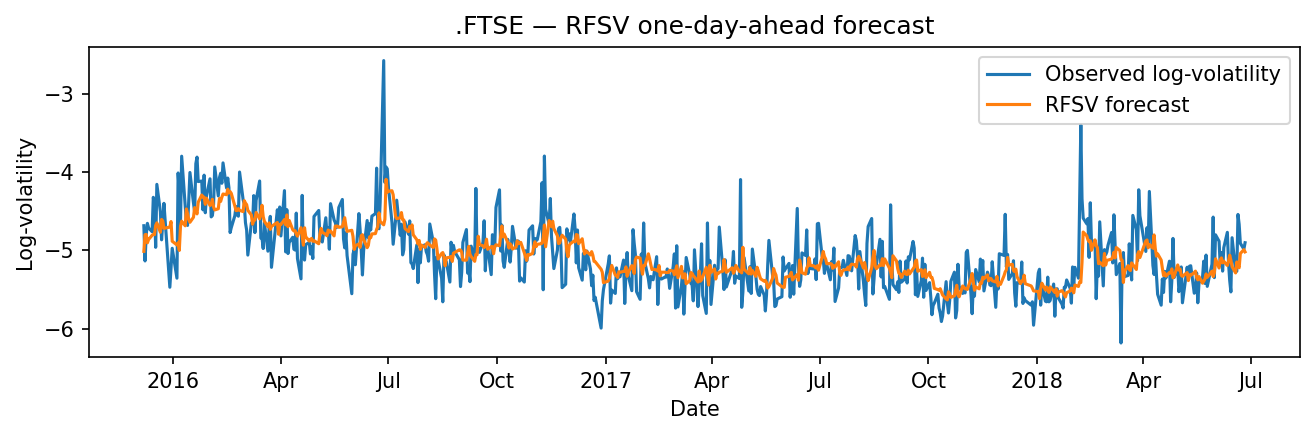

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_FTSE.png


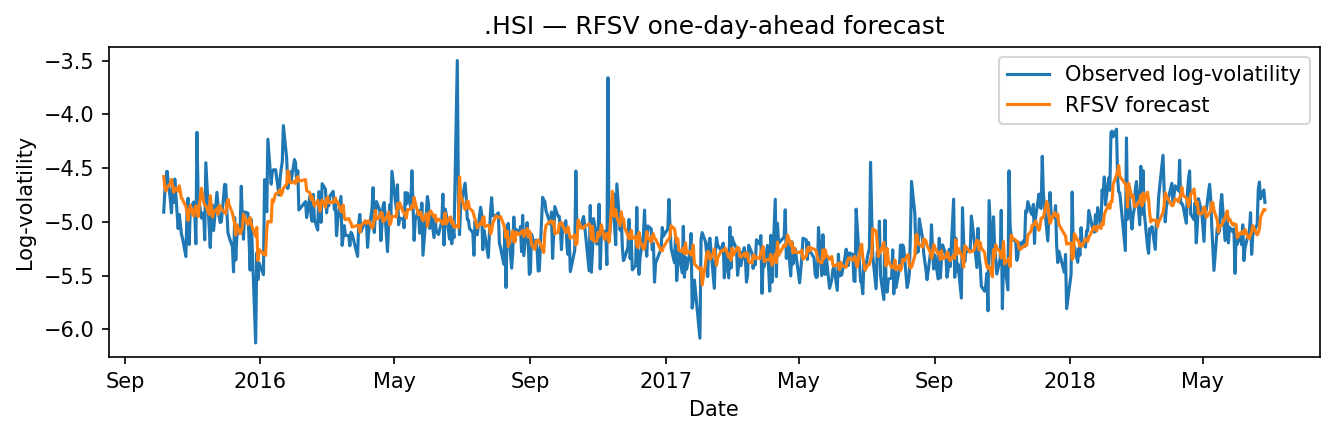

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_HSI.png


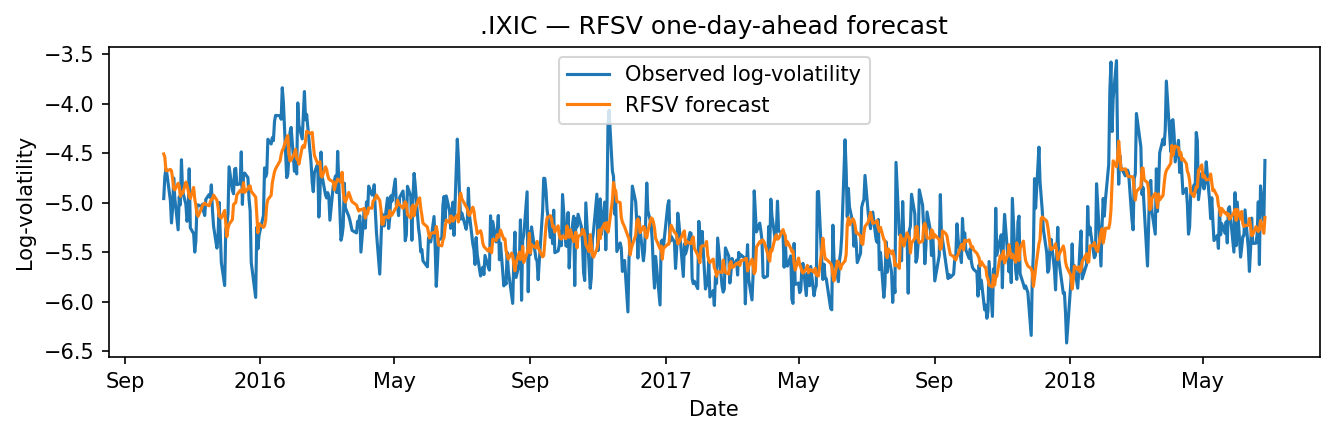

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_IXIC.png


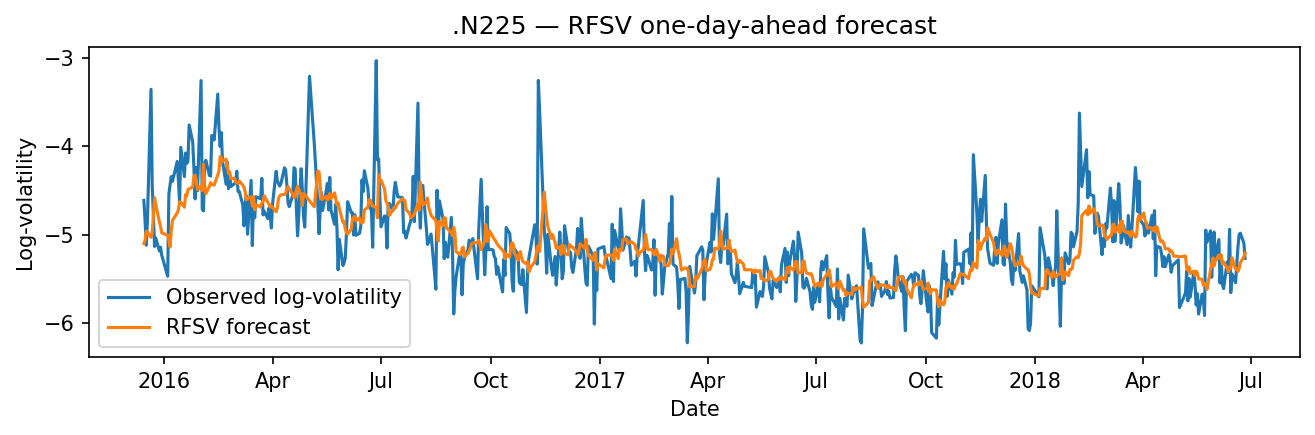

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_N225.png


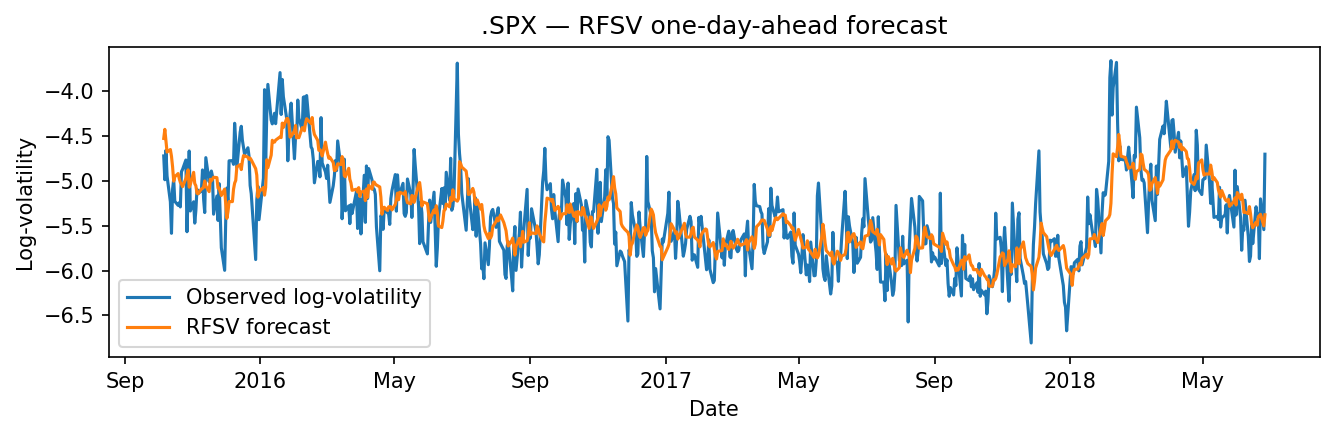

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_SPX.png


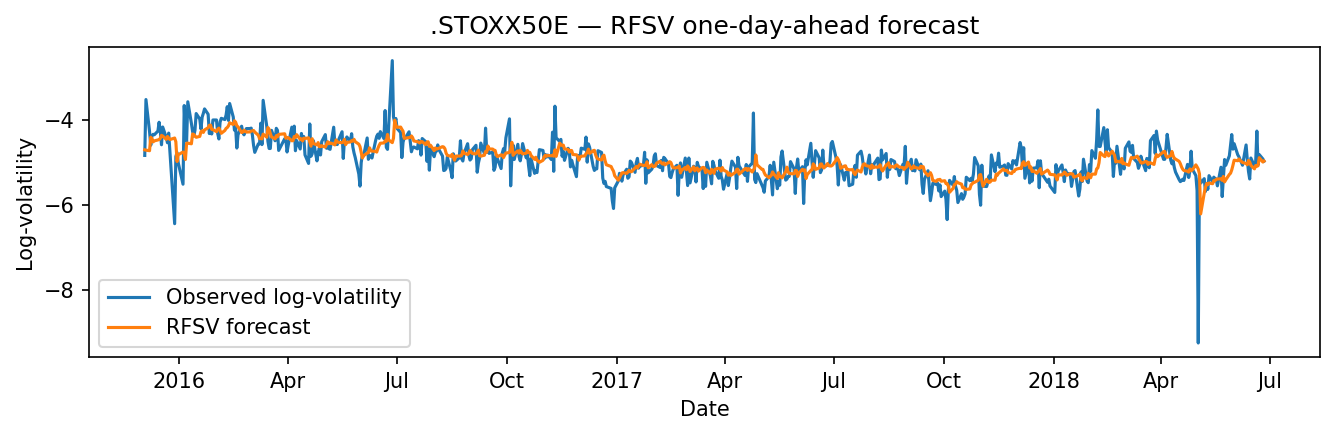

Saved figure: /content/drive/MyDrive/thesis/results/figures/rfsv_forecast_STOXX50E.png


In [3]:
# ============================================================
# RFSV FORECAST PLOTS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for symbol in available_symbols:

    pred_path = f"{PRED_DIR}/pred_test_{symbol}_RFSV.csv"

    if not os.path.exists(pred_path):
        print(f"Missing prediction file for {symbol}")
        continue

    pred_df = pd.read_csv(
        pred_path,
        parse_dates=["Date", "Date_target"]
    )

    pred_df = pred_df.sort_values("Date_target").reset_index(drop=True)

    plt.figure(figsize=(9, 3), dpi=150)

    plt.plot(
        pred_df["Date_target"],
        pred_df["y_true"],
        label="Observed log-volatility"
    )

    plt.plot(
        pred_df["Date_target"],
        pred_df["y_pred_RFSV"],
        label="RFSV forecast"
    )

    plt.title(f"{symbol} — RFSV one-day-ahead forecast")
    plt.xlabel("Date")
    plt.ylabel("Log-volatility")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
    )

    plt.legend()
    plt.tight_layout()

    figure_path = f"{FIG_DIR}/rfsv_forecast_{symbol.replace('.', '')}.png"

    plt.savefig(
        figure_path,
        bbox_inches="tight",
        dpi=150
    )

    plt.show()

    print(f"Saved figure: {figure_path}")